In [22]:
# Imports principales
import numpy as np
import pandas as pd  # Añadido para las gráficas de precisión
import matplotlib.pyplot as plt

# Modelos y métricas
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline

# Carga de imágenes (asumiendo que estas funciones están en tu entorno)
import os
from skimage.io import imread
from skimage.transform import resize
from collections import Counter

In [24]:
# Celda 2: Función para cargar imágenes
def load_image_dataset(root_dir, size=(64,64), max_per_class=None):
    X, y = [], []
    classes = sorted(os.listdir(root_dir))
    for cls in classes:
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg'))]
        if max_per_class:
            files = files[:max_per_class]
        for f in files:
            img = imread(os.path.join(cls_path, f))
            if img.ndim == 3:  # convertir a escala de grises si es RGB
                img = img[...,0]
            img_resized = resize(img, size, anti_aliasing=True)
            X.append(img_resized)
            y.append(cls)
    return np.array(X), np.array(y), classes

In [25]:
# Celda 3: Carga de datos
# Cambia la ruta por la carpeta donde tengas las imágenes
X, y, classes = load_image_dataset("CMS_data", size=(64,64))
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases:", classes)

Shape de X: (60000, 64, 64)
Shape de y: (60000,)
Clases: ['electron', 'muon', 'neutrino', 'proton', 'quark', 'tau']


In [26]:
# Celda 4: Normalización y división de datos
# Normalizar al rango [0,1]
X = X / X.max()

# Aplanar imágenes para modelos clásicos
X_flat = X.reshape(len(X), -1)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (48000, 4096) Test: (12000, 4096)


In [27]:
# Binarizar las etiquetas (necesario para ROC multiclase)
# !! ESTA CELDA DEBE IR DESPUÉS DE LA DIVISIÓN TRAIN/TEST !!
# Corregido: Usamos 'classes' (la lista de strings) en lugar de np.arange
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]
print(f"Número de clases: {n_classes}")

Número de clases: 6


In [28]:
# Función para graficar ROC (basada en tu referencia)
def plot_multiclass_roc(y_test_bin, y_score, classes, title):
    plt.figure(figsize=(8,6))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")
    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [29]:
# --- Decision Tree ---
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Clasificación Decision Tree:\n")
print(classification_report(y_test, y_pred_dt, target_names=classes))

Clasificación Decision Tree:

              precision    recall  f1-score   support

    electron       0.37      0.40      0.38      2000
        muon       0.34      0.37      0.35      2000
    neutrino       0.42      0.43      0.43      2000
      proton       0.87      0.83      0.85      2000
       quark       0.89      0.86      0.87      2000
         tau       0.44      0.39      0.41      2000

    accuracy                           0.55     12000
   macro avg       0.55      0.55      0.55     12000
weighted avg       0.55      0.55      0.55     12000



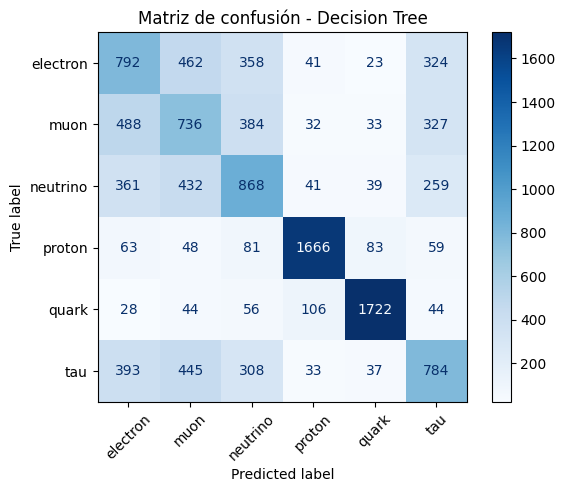

In [30]:
# Matriz de confusión para Decision Tree (basada en tu referencia)
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=classes)

# Añadido cmap y xticks_rotation de tu referencia
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión - Decision Tree")
plt.show()

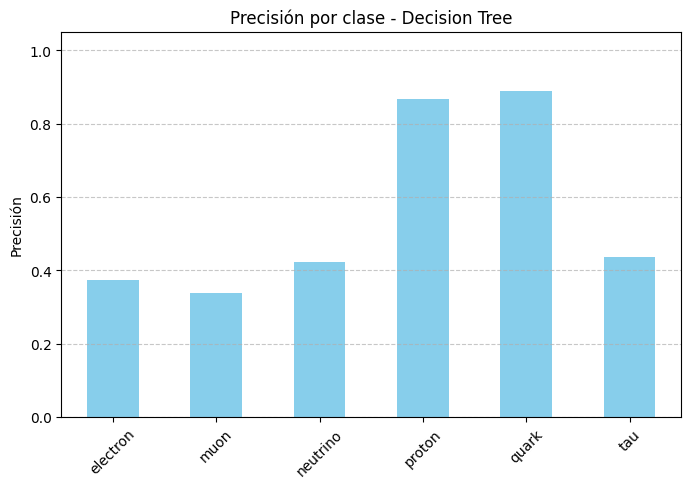

In [31]:
# Gráfica de Precisión por clase para Decision Tree (basada en tu referencia)
report_dt_dict = classification_report(y_test, y_pred_dt, output_dict=True, target_names=classes)
df_dt = pd.DataFrame(report_dt_dict).transpose()

plt.figure(figsize=(8,5))
df_dt.loc[classes, "precision"].plot(kind="bar", color="skyblue")
plt.title("Precisión por clase - Decision Tree")
plt.ylabel("Precisión")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

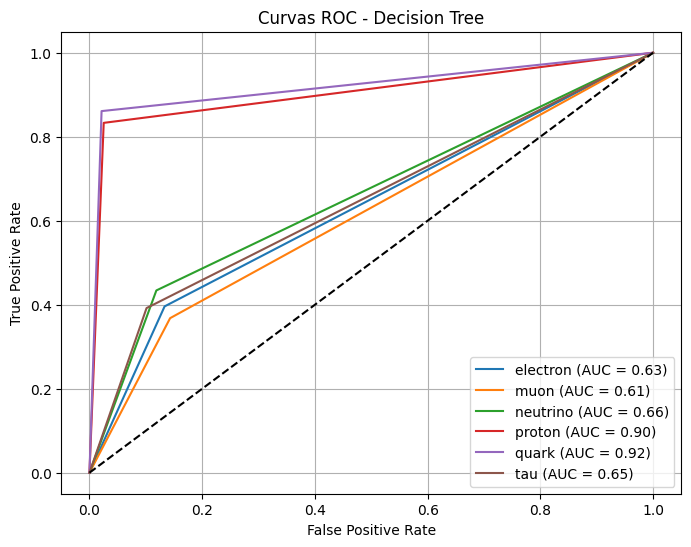

In [32]:
# Curvas ROC para Decision Tree (¡CORREGIDO!)
# Usamos predict_proba ya que es un clasificador que lo soporta
y_score_dt = dt.predict_proba(X_test)

# Usamos la función definida en el Paso 4
plot_multiclass_roc(y_test_bin, y_score_dt, classes, "Curvas ROC - Decision Tree")

In [33]:
# --- SGDClassifier ---
sgd = SGDClassifier(loss="log_loss", max_iter=2000, random_state=42)
sgd.fit(X_train, y_train)

y_pred_sgd = sgd.predict(X_test)

print("Clasificación SGDClassifier:\n")
print(classification_report(y_test, y_pred_sgd, target_names=classes))

Clasificación SGDClassifier:

              precision    recall  f1-score   support

    electron       0.32      0.33      0.32      2000
        muon       0.30      0.29      0.30      2000
    neutrino       0.53      0.54      0.53      2000
      proton       1.00      0.98      0.99      2000
       quark       0.99      0.98      0.98      2000
         tau       0.43      0.45      0.44      2000

    accuracy                           0.59     12000
   macro avg       0.60      0.59      0.59     12000
weighted avg       0.60      0.59      0.59     12000



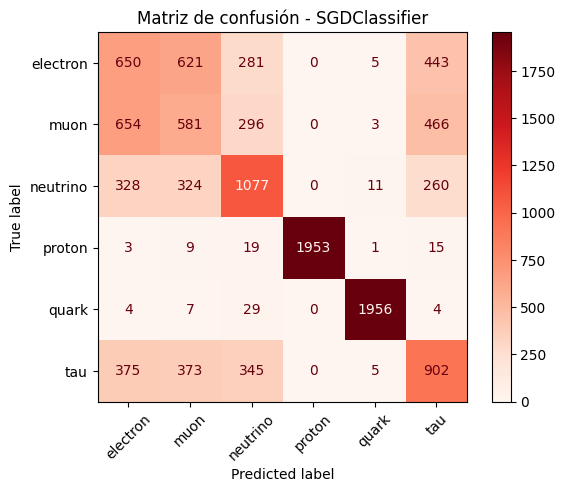

In [34]:
# Matriz de confusión para SGD (basada en tu referencia)
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sgd, display_labels=classes)

# Añadido cmap y xticks_rotation de tu referencia
disp.plot(cmap="Reds", xticks_rotation=45)
plt.title("Matriz de confusión - SGDClassifier")
plt.show()

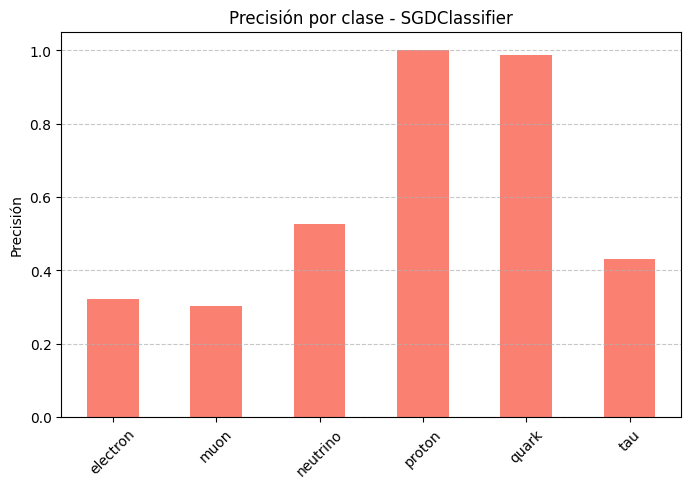

In [35]:
# Gráfica de Precisión por clase para SGD (basada en tu referencia)
report_sgd_dict = classification_report(y_test, y_pred_sgd, output_dict=True, target_names=classes)
df_sgd = pd.DataFrame(report_sgd_dict).transpose()

plt.figure(figsize=(8,5))
df_sgd.loc[classes, "precision"].plot(kind="bar", color="salmon")
plt.title("Precisión por clase - SGDClassifier")
plt.ylabel("Precisión")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

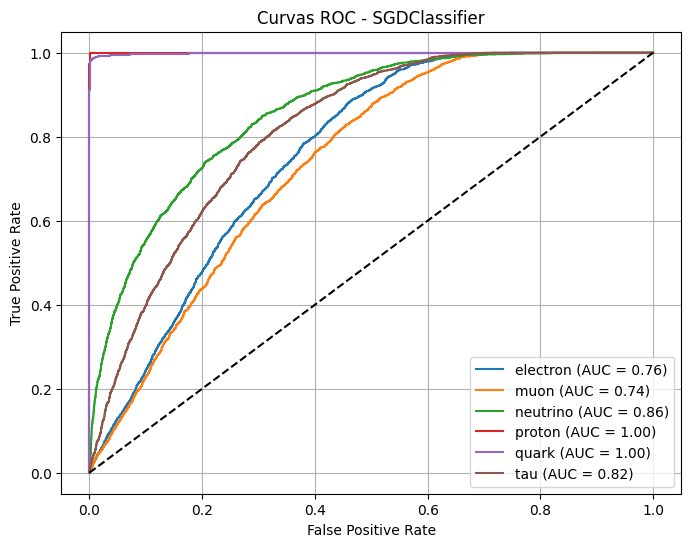

In [36]:
# Curvas ROC para SGDClassifier (¡CORREGIDO!)
# Corregido: Usamos predict_proba() ya que usamos loss="log_loss"
y_score_sgd = sgd.predict_proba(X_test)

# Usamos la función definida en el Paso 4
plot_multiclass_roc(y_test_bin, y_score_sgd, classes, "Curvas ROC - SGDClassifier")

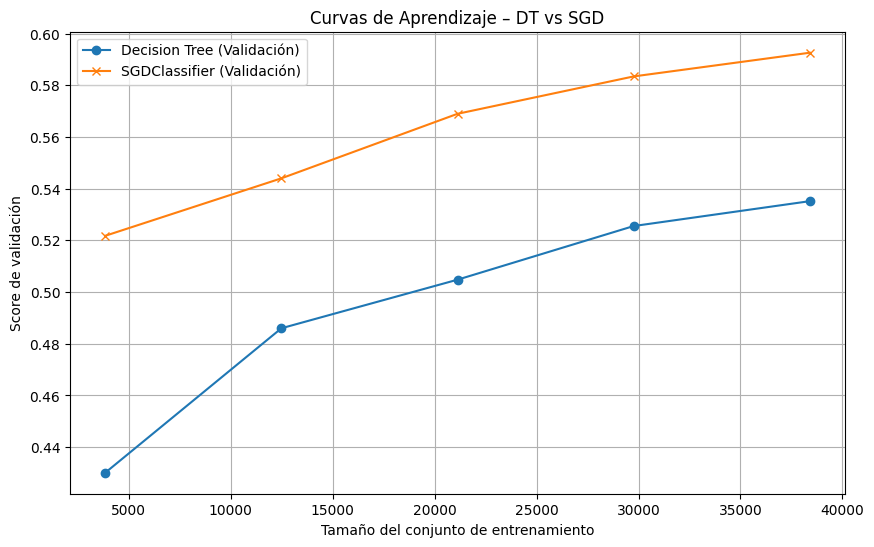

In [37]:
# Curvas de Aprendizaje Comparativas (Opcional)
train_sizes = np.linspace(0.1, 1.0, 5)

plt.figure(figsize=(10,6))

# Decision Tree
train_sizes_dt, train_scores_dt, val_scores_dt = learning_curve(
    dt, X_train, y_train, cv=5, train_sizes=train_sizes
)

# SGD
train_sizes_sgd, train_scores_sgd, val_scores_sgd = learning_curve(
    sgd, X_train, y_train, cv=5, train_sizes=train_sizes
)

plt.plot(train_sizes_dt, np.mean(val_scores_dt, axis=1), label="Decision Tree (Validación)", marker='o')
plt.plot(train_sizes_sgd, np.mean(val_scores_sgd, axis=1), label="SGDClassifier (Validación)", marker='x')

plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Score de validación")
plt.title("Curvas de Aprendizaje – DT vs SGD")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)):
    """
    Genera una gráfica de la curva de aprendizaje para un estimador dado.
    """
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Ejemplos de entrenamiento")
    plt.ylabel("Score (Accuracy)")
    
    # Calcula las curvas de aprendizaje
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="accuracy"
    )
    
    # Calcula promedios y desviaciones estándar
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid(True)
    
    # Rellena el área de la desviación estándar
    plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    # Grafica las curvas de promedio
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r",
             label="Score de Entrenamiento (Train)")
    plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="g",
             label="Score de Validación (Test/CV)")
    
    plt.legend(loc="best")
    plt.show()

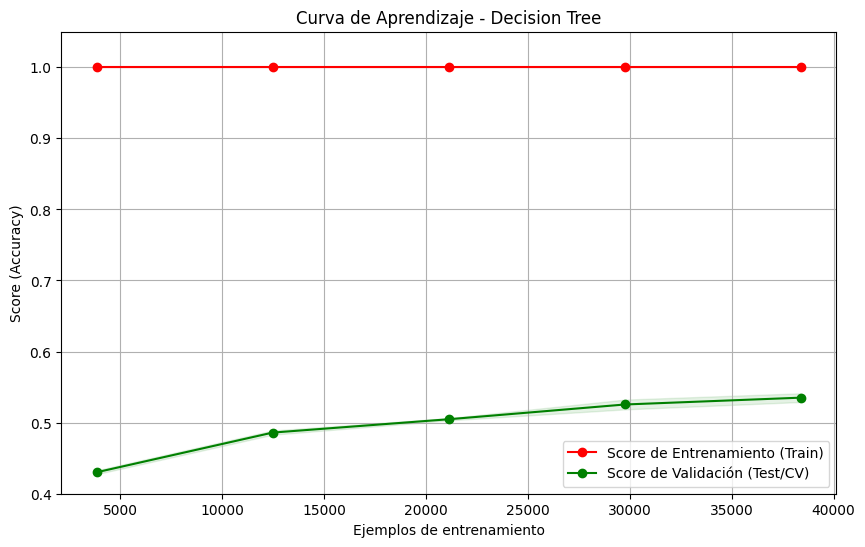

In [39]:
# Graficar para Decision Tree
# Usamos X_train y y_train completos, la función se encarga del CV
plot_learning_curve(dt, "Curva de Aprendizaje - Decision Tree", X_train, y_train, cv=5, ylim=(0.4, 1.05))

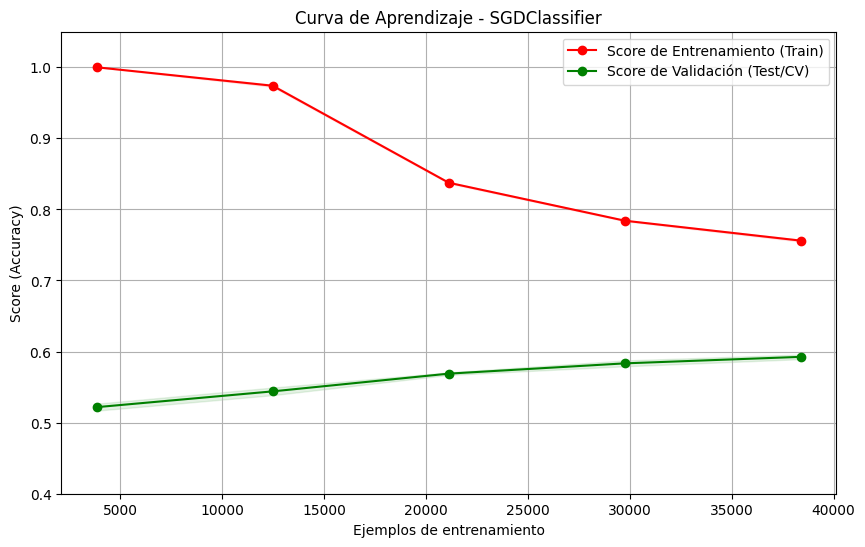

In [40]:
# Graficar para SGDClassifier
plot_learning_curve(sgd, "Curva de Aprendizaje - SGDClassifier", X_train, y_train, cv=5, ylim=(0.4, 1.05))